<a href="https://colab.research.google.com/github/kurotiyamitali-dotcom/Python-basic-project/blob/main/optionaltask2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [4]:
df = pd.read_csv("Train.csv")

In [5]:
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [6]:
df.isnull().sum()

,0
POSTED_BY,0
UNDER_CONSTRUCTION,0
RERA,0
BHK_NO.,0
BHK_OR_RK,0
SQUARE_FT,0
READY_TO_MOVE,0
RESALE,0
ADDRESS,0
LONGITUDE,0


In [7]:
df.duplicated().sum()

np.int64(401)

In [8]:
df.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


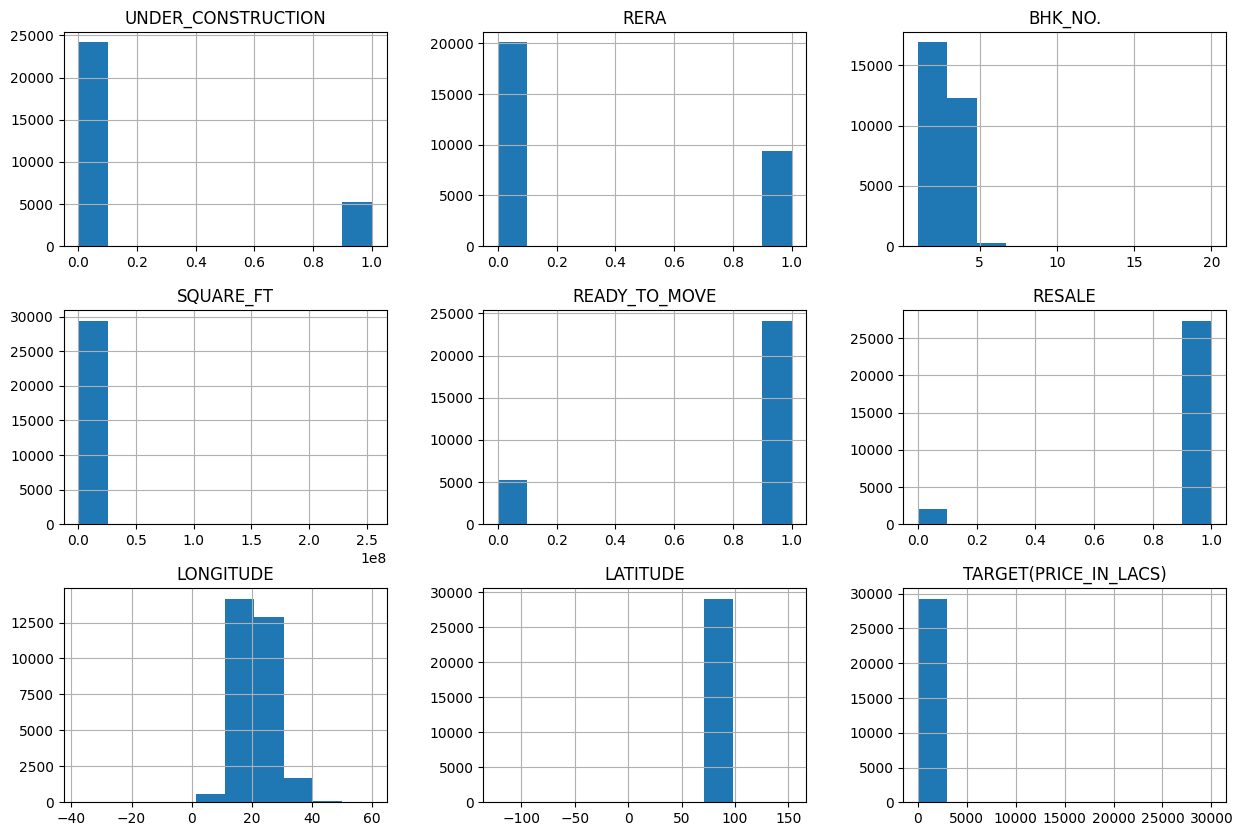

In [9]:
df.hist(figsize=(15,10))
plt.show()

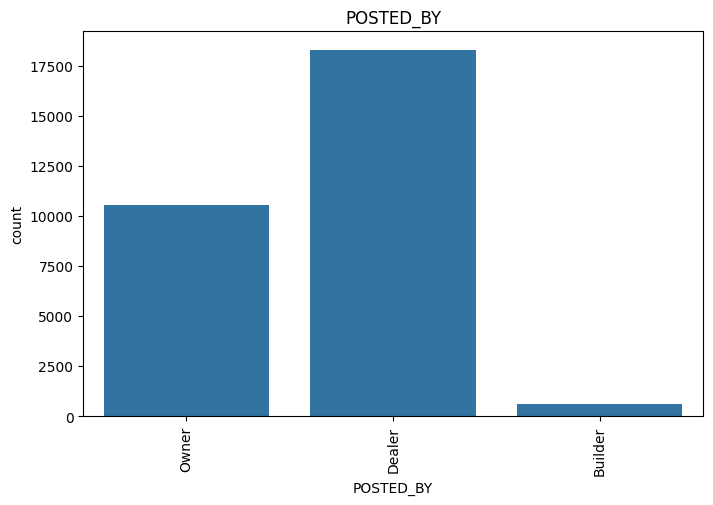

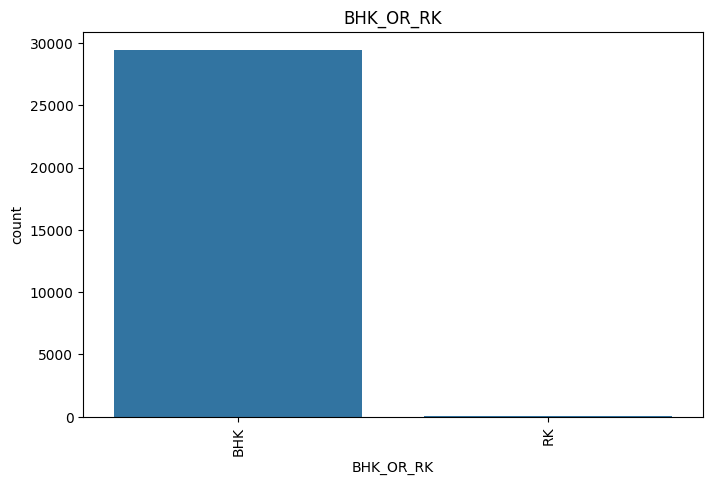

In [10]:
categorical = df.select_dtypes(include="object").columns

for col in categorical:
    if col != "ADDRESS":
        plt.figure(figsize=(8,5))
        sns.countplot(x=df[col])
        plt.xticks(rotation=90)
        plt.title(col)
        plt.show()

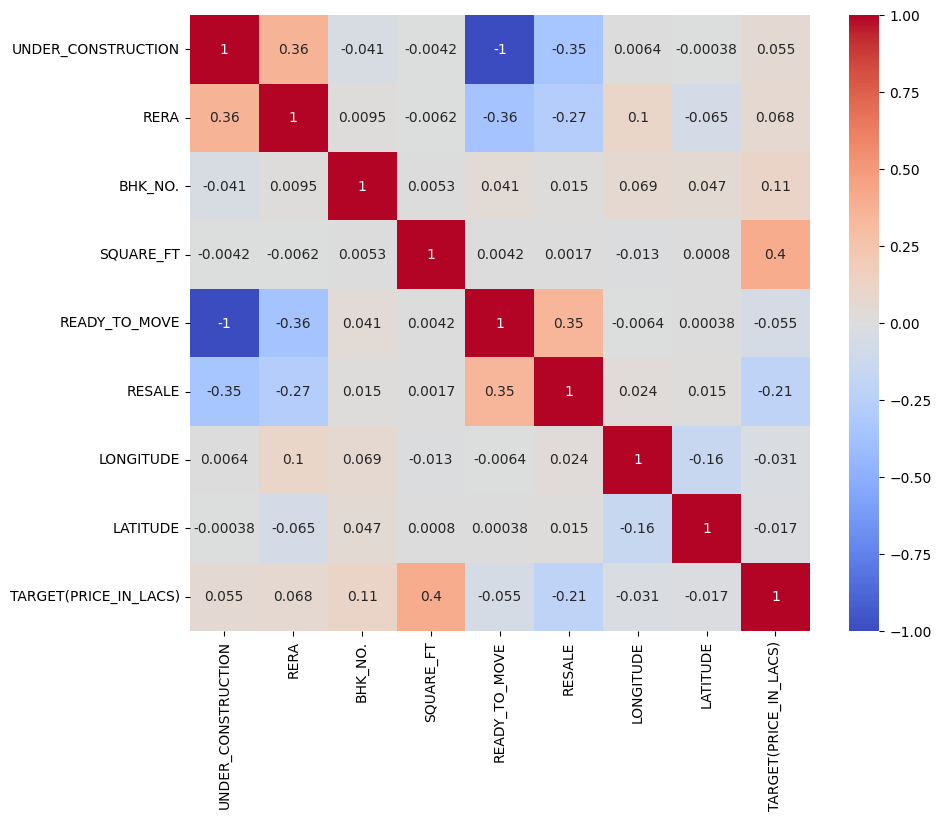

In [11]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.show()

In [20]:
X = df.drop("TARGET(PRICE_IN_LACS)", axis=1)
y = df["TARGET(PRICE_IN_LACS)"]
X = pd.get_dummies(X, drop_first=True)
X.head()
y.head()


,TARGET(PRICE_IN_LACS)
0,55.0
1,51.0
2,43.0
3,62.5
4,60.5


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X)

[[-0.46813431 -0.68271456 -0.44623962 ... -0.00582717 -0.00582717
  -0.00582717]
 [-0.46813431 -0.68271456 -0.44623962 ... -0.00582717 -0.00582717
  -0.00582717]
 [-0.46813431 -0.68271456 -0.44623962 ... -0.00582717 -0.00582717
  -0.00582717]
 ...
 [-0.46813431 -0.68271456 -0.44623962 ... -0.00582717 -0.00582717
  -0.00582717]
 [-0.46813431 -0.68271456 -0.44623962 ... -0.00582717 -0.00582717
  -0.00582717]
 [-0.46813431  1.464741   -0.44623962 ... -0.00582717 -0.00582717
  -0.00582717]]


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train[:5]

array([[ 2.13613911, -0.68271456, -0.44623962, ..., -0.00582717,
        -0.00582717, -0.00582717],
       [-0.46813431, -0.68271456,  0.69131798, ..., -0.00582717,
        -0.00582717, -0.00582717],
       [ 2.13613911,  1.464741  ,  4.10399077, ..., -0.00582717,
        -0.00582717, -0.00582717],
       [-0.46813431, -0.68271456,  0.69131798, ..., -0.00582717,
        -0.00582717, -0.00582717],
       [-0.46813431, -0.68271456, -0.44623962, ..., -0.00582717,
        -0.00582717, -0.00582717]])

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[   54.30141908   158.28294134    18.7026198     93.50598694
   -25.28027168   229.6451837    -41.69794168    -4.99828229
 -1249.82580679  -793.14979662]


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -110755.97049897231
MAE: 5392.662901456004


In [19]:
import joblib

joblib.dump(model, "House_Price_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
